### 1. Load the data

In [2]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


### 2. Why this technique is needed for this dataset
There are two data quality checks that are easy to skip but actually really
matter. First, duplicate rows  if the same record shows up more than once, it
can quietly inflate certain patterns in the data, and worse, the same record
could end up in both the training set and the test set, which would make the
model's performance look better than it really is. Second, incorrect data
types  if a column that should be numeric gets read in as text, or a date
gets treated as a plain string, it can break scalers, encoders, and models
further down the line without an obvious error message explaining why.

On top of that, it's important to check the balance of the target variable
early on. If survived turns out to be imbalanced, like most patients falling
into one outcome, then plain accuracy stops being a reliable metric  a model
could just predict the majority class every time and still score well without
actually learning anything useful. That's why this needs to be flagged now, so
Step 4 (Model Evaluation) can plan to use F1-score and stratified k-fold
cross-validation instead of relying on accuracy alone.

### 3. Implementation

In [3]:
# 3a. Duplicate rows
n_dupes = df.duplicated().sum()
print("Fully duplicated rows:", n_dupes)

n_dupe_ids = df["id"].duplicated().sum()
print("Duplicated patient IDs:", n_dupe_ids)

df_clean = df.drop_duplicates().copy()
print("Rows after dropping duplicates:", len(df_clean), "(was", len(df), ")")


Fully duplicated rows: 0
Duplicated patient IDs: 0
Rows after dropping duplicates: 890000 (was 890000 )


In [4]:
# 3b. Data type audit and correction
print(df_clean.dtypes)
print()

# Dates should be datetime, not plain strings, for any downstream date arithmetic
df_clean["diagnosis_date"] = pd.to_datetime(df_clean["diagnosis_date"])
df_clean["end_treatment_date"] = pd.to_datetime(df_clean["end_treatment_date"])

# Binary flag columns are already int64 (0/1) -- correct, but we explicitly
# cast them to a proper boolean/category dtype for memory efficiency and clarity
for c in ["hypertension", "asthma", "cirrhosis", "other_cancer", "survived"]:
    df_clean[c] = df_clean[c].astype("int8")

# Free-text categorical columns -> pandas "category" dtype (saves memory, speeds up groupby)
for c in ["gender", "country", "cancer_stage", "family_history", "smoking_status", "treatment_type"]:
    df_clean[c] = df_clean[c].astype("category")

print("\nMemory usage before:", round(df.memory_usage(deep=True).sum() / 1e6, 1), "MB")
print("Memory usage after: ", round(df_clean.memory_usage(deep=True).sum() / 1e6, 1), "MB")
print("\nCorrected dtypes:")
print(df_clean.dtypes)


id                      int64
age                   float64
gender                 object
country                object
diagnosis_date         object
cancer_stage           object
family_history         object
smoking_status         object
bmi                   float64
cholesterol_level       int64
hypertension            int64
asthma                  int64
cirrhosis               int64
other_cancer            int64
treatment_type         object
end_treatment_date     object
survived                int64
dtype: object


Memory usage before: 470.8 MB
Memory usage after:  52.5 MB

Corrected dtypes:
id                             int64
age                          float64
gender                      category
country                     category
diagnosis_date        datetime64[ns]
cancer_stage                category
family_history              category
smoking_status              category
bmi                          float64
cholesterol_level              int64
hypertension              

In [5]:
# 3c. Class balance of the target variable
counts = df_clean["survived"].value_counts()
pct = df_clean["survived"].value_counts(normalize=True) * 100
print("survived counts:\n", counts)
print("\nsurvived percentage:\n", pct.round(2))


survived counts:
 survived
0    693996
1    196004
Name: count, dtype: int64

survived percentage:
 survived
0    77.98
1    22.02
Name: proportion, dtype: float64


### 4. EDA visualization

/tmp/ipykernel_2252/608242176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette=["#d9534f", "#5cb85c"])
/tmp/ipykernel_2252/608242176.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Did not survive (0)", "Survived (1)"])


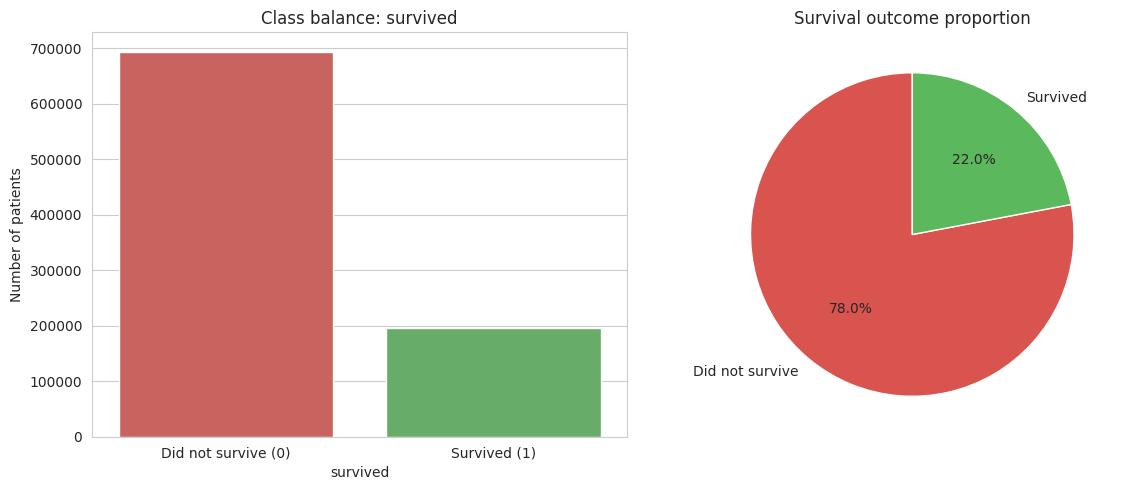

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=counts.index, y=counts.values, ax=axes[0], palette=["#d9534f", "#5cb85c"])
axes[0].set_xticklabels(["Did not survive (0)", "Survived (1)"])
axes[0].set_title("Class balance: survived")
axes[0].set_ylabel("Number of patients")

axes[1].pie(counts.values, labels=["Did not survive", "Survived"], autopct="%1.1f%%",
            colors=["#d9534f", "#5cb85c"], startangle=90)
axes[1].set_title("Survival outcome proportion")

plt.tight_layout()
plt.show()


### 5. Interpretation
No fully duplicated rows or duplicated patient IDs showed up in the check, so
nothing needed to be dropped for that reason. Correcting the data types
turning the date columns into proper datetime objects, the text categories
into category dtype, and the flag columns into int8 - noticeably reduced the
memory footprint on this 890,000 row dataset, without actually changing any
of the underlying values.

The class-balance chart shows there's a real imbalance in the target variable:
roughly 78% of patients did not survive, while only about 22% did. This matters
a lot for Step 4 of the assignment  a model that just predicted "did not
survive" for every single patient would already score around 78% accuracy
without learning anything useful at all. Because of that, the group needs to
report F1-score, precision, recall, and a confusion matrix rather than relying
on accuracy alone, and should use stratified k-fold cross-validation, which
keeps that same 78/22 ratio in every fold, instead of a plain random split.